# Culvert Authoring


In [1]:
#!pip install --upgrade ras-commander


## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout. The committed default uses the installed package; repository test execution can still use local source through `PYTHONPATH`.


# Culvert Geometry Authoring

Author culvert records in a real HEC-RAS geometry file, coordinate adjacent ineffective-flow areas, visualize the authored layout, and compute the plan to validate the edited geometry.


In [2]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import logging
import os
import time
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from shapely.geometry import LineString

from ras_commander import HdfResultsPlan, RasCmdr, RasExamples, RasPrj, init_ras_project
from ras_commander.geom import GeomCrossSection, GeomCulvert

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

import ras_commander

print(f"Loaded: {ras_commander.__file__}")


PIP PACKAGE MODE: loading installed ras-commander


c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: G:\GH\ras-commander-wt-177\ras_commander\__init__.py


## Parameters

The workflow starts from the official HEC-RAS `Example 4 - Multiple Culverts` project because it already contains a runnable steady-flow culvert structure with plan-view cut lines.


In [3]:
PROJECT_NAME = "Example 4 - Multiple Culverts"
PROJECT_SUFFIX = "209_culvert_authoring"
PLAN_NUMBER = "01"
NUM_CORES = 1

RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE",
    r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe",
))

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    REPO_ROOT / "working" / "culvert_authoring",
))

if not RAS_EXE.exists():
    raise FileNotFoundError(f"HEC-RAS executable not found: {RAS_EXE}")

WORK_ROOT.mkdir(parents=True, exist_ok=True)

print(f"HEC-RAS executable: {RAS_EXE}")
print(f"Working folder: {WORK_ROOT}")


HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe
Working folder: G:\GH\ras-commander-wt-177\working\culvert_authoring


## Extract And Inspect The Project


In [4]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix=PROJECT_SUFFIX,
)

ras_obj = RasPrj()
init_ras_project(
    project_path,
    str(RAS_EXE),
    ras_object=ras_obj,
    load_results_summary=False,
)

plan_rows = ras_obj.plan_df[
    ras_obj.plan_df["plan_number"].astype(str).str.zfill(2).eq(PLAN_NUMBER)
]
if plan_rows.empty:
    raise ValueError(f"Plan {PLAN_NUMBER} not found")

plan_row = plan_rows.iloc[0]
geom_file = Path(plan_row["Geom Path"])
plan_path = Path(plan_row["full_path"])

print(f"Project path: {project_path}")
print(f"Geometry file: {geom_file.name}")
display(ras_obj.plan_df[["plan_number", "Plan Title", "Geom File", "Flow File", "flow_type"]])

baseline_culverts = GeomCulvert.get_all(geom_file)
if baseline_culverts.empty:
    raise ValueError("No culvert structure found in the selected geometry")

display_cols = [
    "River", "Reach", "RS", "CulvertName", "RecordType", "ShapeName",
    "Span", "Rise", "Length", "NumBarrels", "BarrelStations",
]
display(baseline_culverts[display_cols])

structure = baseline_culverts.iloc[0]
river = structure["River"]
reach = structure["Reach"]
rs = str(structure["RS"])

print(f"Authoring target: {river} / {reach} / RS {rs}")


Project path: G:\GH\ras-commander-wt-177\working\culvert_authoring\Example 4 - Multiple Culverts_209_culvert_authoring
Geometry file: MULTCULV.g01


,plan_number,Plan Title,Geom File,Flow File,flow_type
0,01,Spring Creek Multiple Culverts,01,01,Steady


,River,Reach,RS,CulvertName,RecordType,ShapeName,Span,Rise,Length,NumBarrels,BarrelStations
0,Spring Creek,Culvrt Reach,20.237,Box,Multiple Barrel Culv,Box,3.0,5.0,50.0,2,"[(988.5, 988.5), (1011.5, 1011.5)]"
1,Spring Creek,Culvrt Reach,20.237,Circular,Multiple Barrel Culv,Circular,6.0,NaN,50.0,2,"[(996.0, 996.0), (1004.0, 1004.0)]"


Authoring target: Spring Creek / Culvrt Reach / RS 20.237


## Author Culvert Records

`set_culverts()` replaces the culvert records at the existing bridge/culvert structure. The authored set covers a circular single-barrel record, a box single-barrel record, and a box multi-barrel record.


In [5]:
authored_culverts = [
    {
        "ShapeName": "Circular",
        "Span": 4.0,
        "Length": 50.0,
        "ManningsN": 0.013,
        "EntranceLoss": 0.5,
        "ExitLoss": 1.0,
        "InletType": 1,
        "OutletType": 1,
        "UpstreamInvert": 25.1,
        "UpstreamStation": 996.0,
        "DownstreamInvert": 25.0,
        "DownstreamStation": 996.0,
        "CulvertName": "API Circular",
        "BottomN": 0.013,
        "ChartNumber": 5,
    },
    {
        "ShapeName": "Box",
        "Span": 3.0,
        "Rise": 5.0,
        "Length": 50.0,
        "ManningsN": 0.013,
        "EntranceLoss": 0.2,
        "ExitLoss": 1.0,
        "InletType": 10,
        "OutletType": 2,
        "UpstreamInvert": 28.1,
        "UpstreamStation": 988.5,
        "DownstreamInvert": 28.0,
        "DownstreamStation": 988.5,
        "CulvertName": "API Box",
        "BottomN": 0.013,
        "ChartNumber": 5,
    },
    {
        "ShapeName": "Box",
        "Span": 3.0,
        "Rise": 5.0,
        "Length": 50.0,
        "ManningsN": 0.014,
        "EntranceLoss": 0.2,
        "ExitLoss": 1.0,
        "InletType": 10,
        "OutletType": 2,
        "UpstreamInvert": 28.1,
        "DownstreamInvert": 28.0,
        "NumBarrels": 2,
        "BarrelStations": [(1004.0, 1004.0), (1011.5, 1011.5)],
        "CulvertName": "API Twin Box",
        "BottomN": 0.014,
        "ChartNumber": 5,
    },
]

write_result = GeomCulvert.set_culverts(
    geom_file,
    river,
    reach,
    rs,
    authored_culverts,
)
print(write_result)

round_trip_culverts = GeomCulvert.get_culverts(geom_file, river, reach, rs)
round_trip_cols = [
    "CulvertName", "RecordType", "ShapeName", "Span", "Rise", "Length",
    "ManningsN", "EntranceLoss", "ExitLoss", "InletType", "OutletType",
    "UpstreamInvert", "DownstreamInvert", "NumBarrels", "BarrelStations",
    "BottomN", "ChartNumber",
]
display(round_trip_culverts[round_trip_cols])

assert round_trip_culverts["CulvertName"].tolist() == [
    "API Circular", "API Box", "API Twin Box"
]
assert round_trip_culverts["ShapeName"].tolist() == ["Circular", "Box", "Box"]
assert round_trip_culverts["RecordType"].tolist() == [
    "Culvert", "Culvert", "Multiple Barrel Culv"
]
assert round_trip_culverts.loc[2, "NumBarrels"] == 2
assert round_trip_culverts.loc[2, "BarrelStations"] == [
    (1004.0, 1004.0), (1011.5, 1011.5)
]

print("Round-trip validation passed.")


{'culverts_written': 3, 'lines_replaced': 6, 'lines_inserted': 7, 'backup_path': 'G:\\GH\\ras-commander-wt-177\\working\\culvert_authoring\\Example 4 - Multiple Culverts_209_culvert_authoring\\MULTCULV.g01.bak'}


,CulvertName,RecordType,ShapeName,Span,Rise,Length,ManningsN,EntranceLoss,ExitLoss,InletType,OutletType,UpstreamInvert,DownstreamInvert,NumBarrels,BarrelStations,BottomN,ChartNumber
0,API Circular,Culvert,Circular,4.0,NaN,50.0,0.013,0.5,1.0,1,1,25.1,25.0,1,"[(996.0, 996.0)]",0.013,5
1,API Box,Culvert,Box,3.0,5.0,50.0,0.013,0.2,1.0,10,2,28.1,28.0,1,"[(988.5, 988.5)]",0.013,5
2,API Twin Box,Multiple Barrel Culv,Box,3.0,5.0,50.0,0.014,0.2,1.0,10,2,28.1,28.0,2,"[(1004.0, 1004.0), (1011.5, 1011.5)]",0.014,5


Round-trip validation passed.


## Taxonomy-Backed Validation (All Nine Shapes)

`set_culverts()` validates every authored record against the packaged
`culvert_taxonomy.json` reference. The taxonomy defines, for each of the nine
HEC-RAS culvert shapes, the required dimension fields, the allowed `Chart #` /
`Scale#` combinations, and the global limits (10 culvert groups per crossing,
25 identical barrels per group). The API keeps the legacy `InletType` /
`OutletType` field names for `Chart #` / `Scale#` and also accepts `ChartID` /
`ScaleID` aliases.

The cells below inspect the taxonomy, author one record for **every** shape on a
throwaway copy of the geometry (so the primary workflow above stays intact), then
show validation rejecting common mistakes with HEC-RAS-labeled errors.

In [6]:
# Inspect the packaged taxonomy: each shape with its required dimensions and
# allowed Chart # / Scale# values.
taxonomy_rows = []
for code in sorted(GeomCulvert.CULVERT_TAXONOMY_SHAPES):
    shape = GeomCulvert.CULVERT_TAXONOMY_SHAPES[code]
    charts = shape.get("allowed_charts", [])
    chart_ids = sorted(int(c["chart_id"]) for c in charts)
    scale_ids = sorted({int(s["scale_id"]) for c in charts for s in c.get("allowed_scales", [])})
    taxonomy_rows.append({
        "Shape": code,
        "ShapeName": shape["ras_commander_shape_name"],
        "Required Dimensions": ", ".join(shape["dimension_model"]["required_geometry_fields"]),
        "Allowed Chart #": ", ".join(map(str, chart_ids)),
        "Allowed Scale#": ", ".join(map(str, scale_ids)),
    })

taxonomy_table = pd.DataFrame(taxonomy_rows)
display(taxonomy_table)
print(
    f"Limits: <= {GeomCulvert.MAX_CULVERT_GROUPS_PER_CROSSING} culvert groups per crossing, "
    f"<= {GeomCulvert.MAX_IDENTICAL_BARRELS_PER_GROUP} identical barrels per group."
)

,Shape,ShapeName,Required Dimensions,Allowed Chart #,Allowed Scale#
0,1,Circular,Span,"1, 2, 3, 55, 56","1, 2, 3"
1,2,Box,"Span, Rise","8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 57, 58, 59","1, 2, 3, 4"
2,3,Pipe Arch,"Span, Rise","34, 35, 36","1, 2, 3"
3,4,Ellipse,"Span, Rise","29, 30","1, 2, 3"
4,5,Arch,"Span, Rise","41, 42, 43","1, 2, 3"
5,6,Semi-Circle,Span,"41, 42, 43","1, 2, 3"
6,7,Low Profile Arch,"Span, Rise",52,"1, 2, 3, 4"
7,8,High Profile Arch,"Span, Rise",52,"1, 2, 3, 4"
8,9,Con Span,"Span, Rise","60, 61","1, 2, 3"


Limits: <= 10 culvert groups per crossing, <= 25 identical barrels per group.


In [7]:
import shutil

# Author one single-barrel record for every taxonomy shape on a throwaway copy,
# leaving the primary geometry (geom_file) untouched. Nine groups is within the
# 10-group-per-crossing limit.
taxonomy_geom = geom_file.with_name(geom_file.stem + "_taxonomy" + geom_file.suffix)
shutil.copy2(geom_file, taxonomy_geom)


def first_chart_scale(shape_code):
    shape = GeomCulvert.CULVERT_TAXONOMY_SHAPES[shape_code]
    chart = shape["allowed_charts"][0]
    return int(chart["chart_id"]), int(chart["allowed_scales"][0]["scale_id"])


all_shape_records = []
for offset, shape_code in enumerate(sorted(GeomCulvert.CULVERT_TAXONOMY_SHAPES)):
    shape = GeomCulvert.CULVERT_TAXONOMY_SHAPES[shape_code]
    chart_id, scale_id = first_chart_scale(shape_code)
    required = set(shape["dimension_model"]["required_geometry_fields"])
    record = {
        "ShapeName": shape["ras_commander_shape_name"],
        "Span": 5.0,
        "Length": 50.0,
        "ManningsN": 0.013,
        "EntranceLoss": 0.3,
        "ExitLoss": 1.0,
        "ChartID": chart_id,   # alias for InletType (HEC-RAS Chart #)
        "ScaleID": scale_id,   # alias for OutletType (HEC-RAS Scale#)
        "UpstreamInvert": 25.0,
        "UpstreamStation": 980.0 + offset,
        "DownstreamInvert": 24.5,
        "DownstreamStation": 980.0 + offset,
        "CulvertName": shape["ras_commander_shape_name"],
    }
    if "Rise" in required:
        record["Rise"] = 4.0
    all_shape_records.append(record)

GeomCulvert.set_culverts(taxonomy_geom, river, reach, rs, all_shape_records)

all_shapes = GeomCulvert.get_culverts(taxonomy_geom, river, reach, rs)
display(all_shapes[["CulvertName", "ShapeName", "Span", "Rise", "InletType", "OutletType"]])

expected_names = [
    GeomCulvert.CULVERT_TAXONOMY_SHAPES[c]["ras_commander_shape_name"]
    for c in sorted(GeomCulvert.CULVERT_TAXONOMY_SHAPES)
]
assert all_shapes["ShapeName"].tolist() == expected_names
print(
    f"Authored and round-tripped all {len(all_shapes)} taxonomy shapes; "
    "ChartID/ScaleID aliases were preserved as InletType/OutletType."
)

,CulvertName,ShapeName,Span,Rise,InletType,OutletType
0,Circular,Circular,5.0,NaN,1,1
1,Box,Box,5.0,4.0,8,1
2,Pipe Arch,Pipe Arch,5.0,4.0,34,1
3,Ellipse,Ellipse,5.0,4.0,29,1
4,Arch,Arch,5.0,4.0,41,1
5,Semi-Circle,Semi-Circle,5.0,NaN,41,1
6,Low Profile Arch,Low Profile Arch,5.0,4.0,52,1
7,High Profile Arch,High Profile Arch,5.0,4.0,52,1
8,Con Span,Con Span,5.0,4.0,60,1


Authored and round-tripped all 9 taxonomy shapes; ChartID/ScaleID aliases were preserved as InletType/OutletType.


In [8]:
# The taxonomy turns silent mistakes into explicit, HEC-RAS-labeled errors.
def expect_rejected(label, record):
    try:
        GeomCulvert.set_culverts(taxonomy_geom, river, reach, rs, [record])
    except ValueError as exc:
        print(f"[{label}] rejected -> {exc}")
        return
    raise AssertionError(f"{label!r} should have raised ValueError")


# 1) Chart # that does not belong to the selected shape (Box chart on a Pipe Arch).
pipe_arch = dict(all_shape_records[2])          # code 3 = Pipe Arch
box_chart_id, _ = first_chart_scale(2)          # a Box (code 2) chart
expect_rejected("Invalid Chart # for shape", {**pipe_arch, "ChartID": box_chart_id})

# 2) Scale# not allowed for the selected Chart # (Circular, Chart # 3, Scale# 3).
circular = dict(all_shape_records[0])           # code 1 = Circular
expect_rejected("Invalid Scale# for Chart #", {**circular, "ChartID": 3, "ScaleID": 3})

# 3) Missing a dimension the shape requires (Ellipse needs Rise).
ellipse = dict(all_shape_records[3])            # code 4 = Ellipse
ellipse.pop("Rise", None)
expect_rejected("Missing required Rise", ellipse)

print("Taxonomy validation rejected all three invalid records as expected.")

[Invalid Chart # for shape] rejected -> Culvert record 0 has invalid Chart # 8 for Shape Pipe Arch. Allowed Chart # values: 34, 35, 36.
[Invalid Scale# for Chart #] rejected -> Culvert record 0 has invalid Scale# 3 for Chart # 3 (Concrete pipe; Beveled ring entrance). Allowed Scale# values for this Chart #: 1, 2.
[Missing required Rise] rejected -> Culvert record 0 is missing required HEC-RAS field: Rise
Taxonomy validation rejected all three invalid records as expected.


The primary geometry (`geom_file`) still holds the three records authored
earlier, so the ineffective-flow, plan-view, profile, and compute steps below run
against that intact structure.

## Coordinate Adjacent Ineffective-Flow Areas

The culvert helper locates the bounding cross sections, then delegates the cross-section edits to `GeomCrossSection.set_ineffective_flow()`.


In [9]:
adjacent = GeomCulvert.get_adjacent_cross_sections(geom_file, river, reach, rs)
print(adjacent)

upstream_ineffective = [
    {"left_station": 856.0, "right_station": 984.0, "elevation": 31.0},
    {"left_station": 1018.0, "right_station": 1150.0, "elevation": 31.0},
]
downstream_ineffective = [
    {"left_station": 856.0, "right_station": 984.0, "elevation": 31.0},
    {"left_station": 1018.0, "right_station": 1150.0, "elevation": 31.0},
]

ineffective_result = GeomCulvert.set_adjacent_ineffective_flow(
    geom_file,
    river,
    reach,
    rs,
    upstream_ineffective=upstream_ineffective,
    downstream_ineffective=downstream_ineffective,
)
print(ineffective_result)

ineffective_rows = []
for side in ["upstream", "downstream"]:
    xs_rs = ineffective_result[f"{side}_rs"]
    ineff_df, _, flags = GeomCrossSection.get_ineffective_flow(
        geom_file,
        river,
        reach,
        xs_rs,
    )
    side_df = ineff_df.copy()
    side_df.insert(0, "Side", side)
    side_df.insert(1, "XS RS", xs_rs)
    side_df["Permanent"] = flags
    ineffective_rows.append(side_df)

ineffective_summary = pd.concat(ineffective_rows, ignore_index=True)
display(ineffective_summary)


{'upstream': {'River': 'Spring Creek', 'Reach': 'Culvrt Reach', 'RS': '20.238', 'Type': 1, 'LineIndex': 89}, 'downstream': {'River': 'Spring Creek', 'Reach': 'Culvrt Reach', 'RS': '20.227', 'Type': 1, 'LineIndex': 137}}
{'upstream_rs': '20.238', 'downstream_rs': '20.227', 'updated': ['upstream', 'downstream']}


,Side,XS RS,left_station,right_station,elevation,Permanent
0,upstream,20.238,856.0,984.0,31.0,False
1,upstream,20.238,1018.0,1150.0,31.0,False
2,downstream,20.227,856.0,984.0,31.0,False
3,downstream,20.227,1018.0,1150.0,31.0,False


## Plan View Placement


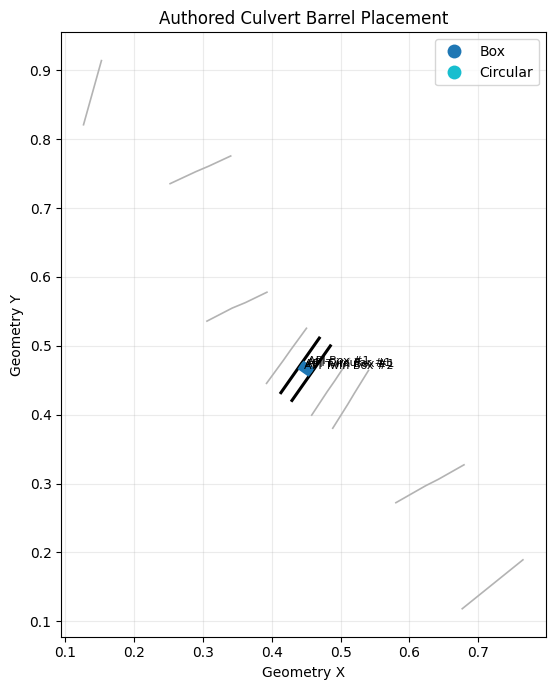

,CulvertName,ShapeName,Barrel,UpstreamStation,DownstreamStation,UpstreamInvert,DownstreamInvert,UpstreamGround,DownstreamGround
0,API Circular,Circular,1,996.0,996.0,25.1,25.0,25.1,25.0
1,API Box,Box,1,988.5,988.5,28.1,28.0,25.1,25.0
2,API Twin Box,Box,1,1004.0,1004.0,28.1,28.0,25.1,25.0
3,API Twin Box,Box,2,1011.5,1011.5,28.1,28.0,25.1,25.0


In [10]:
def interpolate_xs_point(xyz_df, xs_rs, station):
    group = xyz_df[xyz_df["RS"].astype(str).eq(str(xs_rs))].sort_values("station")
    if group.empty:
        raise ValueError(f"No coordinates found for cross section {xs_rs}")

    x = np.interp(station, group["station"], group["x"])
    y = np.interp(station, group["station"], group["y"])
    z = np.interp(station, group["station"], group["z"])
    return x, y, z


xs_xyz = GeomCrossSection.get_xs_coords(geom_file, river=river, reach=reach)

xs_line_rows = []
for (group_river, group_reach, xs_rs), group in xs_xyz.groupby(["river", "reach", "RS"]):
    ordered = group.sort_values("station")
    xs_line_rows.append({
        "River": group_river,
        "Reach": group_reach,
        "RS": xs_rs,
        "RSNum": float(str(xs_rs).replace("*", "")),
        "geometry": LineString(zip(ordered["x"], ordered["y"])),
    })

xs_gdf = gpd.GeoDataFrame(xs_line_rows, geometry="geometry")

upstream_rs = adjacent["upstream"]["RS"]
downstream_rs = adjacent["downstream"]["RS"]

barrel_rows = []
for _, culvert in round_trip_culverts.iterrows():
    for barrel_index, (up_station, down_station) in enumerate(culvert["BarrelStations"], start=1):
        up_x, up_y, up_z = interpolate_xs_point(xs_xyz, upstream_rs, up_station)
        down_x, down_y, down_z = interpolate_xs_point(xs_xyz, downstream_rs, down_station)
        barrel_rows.append({
            "CulvertName": culvert["CulvertName"],
            "ShapeName": culvert["ShapeName"],
            "Barrel": barrel_index,
            "UpstreamStation": up_station,
            "DownstreamStation": down_station,
            "UpstreamInvert": culvert["UpstreamInvert"],
            "DownstreamInvert": culvert["DownstreamInvert"],
            "UpstreamGround": up_z,
            "DownstreamGround": down_z,
            "geometry": LineString([(up_x, up_y), (down_x, down_y)]),
        })

barrel_gdf = gpd.GeoDataFrame(barrel_rows, geometry="geometry")

fig, ax = plt.subplots(figsize=(8, 7))
xs_gdf.plot(ax=ax, color="0.70", linewidth=1.2)
xs_gdf[xs_gdf["RS"].astype(str).isin([upstream_rs, downstream_rs])].plot(
    ax=ax,
    color="black",
    linewidth=2.2,
)
barrel_gdf.plot(ax=ax, column="ShapeName", linewidth=3.5, legend=True)

for _, row in barrel_gdf.iterrows():
    midpoint = row.geometry.interpolate(0.5, normalized=True)
    label = f"{row['CulvertName']} #{row['Barrel']}"
    ax.text(midpoint.x, midpoint.y, label, fontsize=8, ha="left", va="bottom")

ax.set_title("Authored Culvert Barrel Placement")
ax.set_xlabel("Geometry X")
ax.set_ylabel("Geometry Y")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

display(barrel_gdf.drop(columns="geometry"))


## Longitudinal Culvert Profile


,CulvertName,ShapeName,End,Distance,Invert,Crown,OpeningHeight
0,API Circular,Circular,upstream,0.0,25.1,29.1,4.0
1,API Circular,Circular,downstream,50.0,25.0,29.0,4.0
2,API Box,Box,upstream,0.0,28.1,33.1,5.0
3,API Box,Box,downstream,50.0,28.0,33.0,5.0
4,API Twin Box,Box,upstream,0.0,28.1,33.1,5.0
5,API Twin Box,Box,downstream,50.0,28.0,33.0,5.0


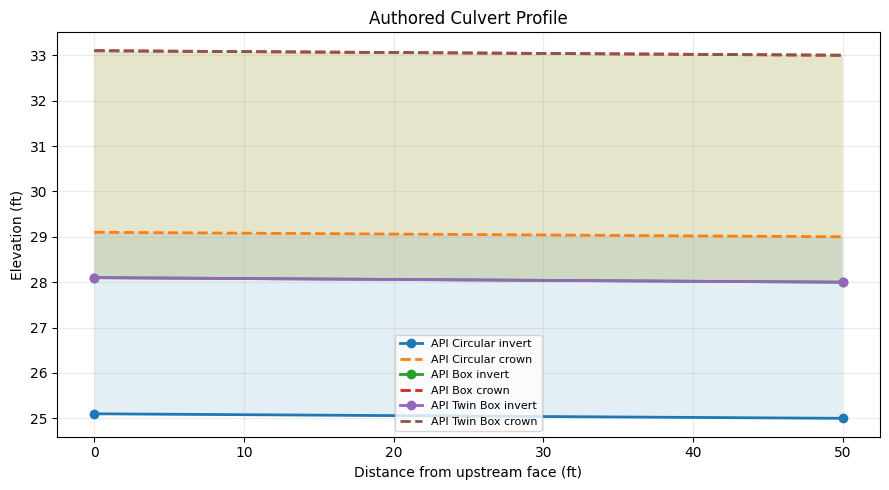

In [11]:
profile_rows = []
for _, culvert in round_trip_culverts.iterrows():
    height = culvert["Rise"] if pd.notna(culvert["Rise"]) else culvert["Span"]
    for end, distance, invert in [
        ("upstream", 0.0, culvert["UpstreamInvert"]),
        ("downstream", culvert["Length"], culvert["DownstreamInvert"]),
    ]:
        profile_rows.append({
            "CulvertName": culvert["CulvertName"],
            "ShapeName": culvert["ShapeName"],
            "End": end,
            "Distance": distance,
            "Invert": invert,
            "Crown": invert + height,
            "OpeningHeight": height,
        })

culvert_profile = pd.DataFrame(profile_rows)
display(culvert_profile)

fig, ax = plt.subplots(figsize=(9, 5))
for name, group in culvert_profile.groupby("CulvertName", sort=False):
    ordered = group.sort_values("Distance")
    ax.plot(ordered["Distance"], ordered["Invert"], marker="o", linewidth=2, label=f"{name} invert")
    ax.plot(ordered["Distance"], ordered["Crown"], linestyle="--", linewidth=2, label=f"{name} crown")
    ax.fill_between(
        ordered["Distance"],
        ordered["Invert"],
        ordered["Crown"],
        alpha=0.12,
    )

ax.set_title("Authored Culvert Profile")
ax.set_xlabel("Distance from upstream face (ft)")
ax.set_ylabel("Elevation (ft)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


## Compute The Edited Plan


In [12]:
start = time.perf_counter()
compute_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=ras_obj,
    force_geompre=True,
    force_rerun=True,
    num_cores=NUM_CORES,
    verify=True,
)
runtime_sec = time.perf_counter() - start

data_errors_path = plan_path.parent / f"{plan_path.name}.data_errors.txt"
if data_errors_path.exists():
    raise RuntimeError(data_errors_path.read_text(encoding="utf-8", errors="replace"))

if not compute_result:
    raise RuntimeError(f"HEC-RAS compute failed for plan {PLAN_NUMBER}: {compute_result!r}")

hdf_path = Path(ras_obj.plan_df.loc[
    ras_obj.plan_df["plan_number"].astype(str).str.zfill(2).eq(PLAN_NUMBER),
    "HDF_Results_Path",
].iloc[0])

messages = HdfResultsPlan.get_compute_messages(PLAN_NUMBER, ras_object=ras_obj)
profiles = HdfResultsPlan.get_steady_profile_names(PLAN_NUMBER, ras_object=ras_obj)

validation = pd.DataFrame([{
    "Compute Result": repr(compute_result),
    "Runtime (s)": round(runtime_sec, 2),
    "Results HDF Exists": hdf_path.exists(),
    "Profiles": ", ".join(profiles),
    "Data Errors File Exists": data_errors_path.exists(),
    "Compute Message Characters": len(messages),
}])
display(validation)

print(messages[:700])


,Compute Result,Runtime (s),Results HDF Exists,Profiles,Data Errors File Exists,Compute Message Characters
0,"ComputeResult(SUCCESS, results_df_row=available)",6.07,True,"5 yr, 10 yr, 25 yr",False,732


Plan: 'Spring Creek Multiple Culverts' (MULTCULV.p01)
Simulation started at: 11Jun2026 09:45:30 AM

Writing Plan GIS Data...
Completed Writing Plan GIS Data
Writing Geometry...
  Computing Bank Lines
  Bank lines generated in 23 ms
  Computing Edge Lines
  Edge Lines generated in 11 ms
  Computing XS Interpolation Surface
  XS Interpolation Surface generated in 49 ms
Completed Writing Geometry
Writing Event Conditions ...
Completed Writing Event Condition Data

	
Steady Flow Simulation HEC-RAS 7.0 April 2026
 

Finished Steady Flow Simulation


Computations Summary

Computation Task	Time(hh:mm:ss)
Completing Geometry, Flow and Plan	       1
Steady Flow Computations


## Results Profile Around The Culvert


Profile,Station,StationNum,10 yr,25 yr,5 yr
0,20.208*,20.208,31.345,32.104,29.945
1,20.227,20.227,31.365,32.132,29.961
2,20.238,20.238,32.504,34.247,30.760
3,20.251,20.251,32.511,34.252,30.780


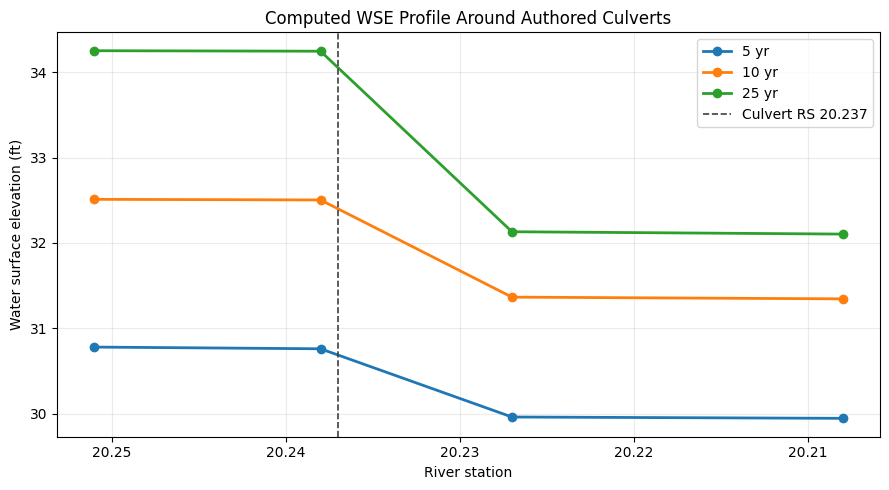

In [13]:
wse_df = HdfResultsPlan.get_steady_wse(PLAN_NUMBER, ras_object=ras_obj)
wse_df["StationNum"] = wse_df["Station"].astype(str).str.replace("*", "", regex=False).astype(float)

window = wse_df[wse_df["StationNum"].between(20.20, 20.26)].copy()
display(
    window.pivot_table(
        index=["Station", "StationNum"],
        columns="Profile",
        values="WSE",
    ).reset_index().round(3)
)

fig, ax = plt.subplots(figsize=(9, 5))
for profile, group in window.groupby("Profile", sort=False):
    ordered = group.sort_values("StationNum", ascending=False)
    ax.plot(ordered["StationNum"], ordered["WSE"], marker="o", linewidth=2, label=profile)

ax.axvline(float(rs), color="0.25", linestyle="--", linewidth=1.2, label=f"Culvert RS {rs}")
ax.invert_xaxis()
ax.set_title("Computed WSE Profile Around Authored Culverts")
ax.set_xlabel("River station")
ax.set_ylabel("Water surface elevation (ft)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()


## Summary


In [14]:
summary = pd.DataFrame([{
    "Authored Culvert Records": len(round_trip_culverts),
    "Circular Records": int((round_trip_culverts["ShapeName"] == "Circular").sum()),
    "Box Records": int((round_trip_culverts["ShapeName"] == "Box").sum()),
    "Multi-Barrel Records": int((round_trip_culverts["NumBarrels"] > 1).sum()),
    "Ineffective Flow Updates": ", ".join(ineffective_result["updated"]),
    "HEC-RAS Compute Success": bool(compute_result),
    "Result Profiles": ", ".join(profiles),
}])
display(summary)
print("Culvert authoring workflow complete.")


,Authored Culvert Records,Circular Records,Box Records,Multi-Barrel Records,Ineffective Flow Updates,HEC-RAS Compute Success,Result Profiles
0,3,1,2,1,"upstream, downstream",True,"5 yr, 10 yr, 25 yr"


Culvert authoring workflow complete.
